## MNIST

In [1]:
%config InlineBackend.figure_format = 'retina'
from sklearn.datasets import fetch_openml
mnist = fetch_openml('mnist_784', version=1)
mnist.keys()

dict_keys(['data', 'target', 'frame', 'categories', 'feature_names', 'target_names', 'DESCR', 'details', 'url'])

as the dataset of sklearn has a dictionary type with `DESCR`,`data` and `target` as keys

In [2]:
X,y = mnist["data"], mnist["target"]
X.shape

(70000, 784)

In [3]:
y.shape

(70000,)

so there are 70000 images each having 784 features (28x28), the images can be shown by matplotlib's imshow funcition, the scikitlearn gives pd.DataFrame but matplotlib uses numpy arrays

In [4]:
X_n = X.to_numpy()
X_n

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(70000, 784))

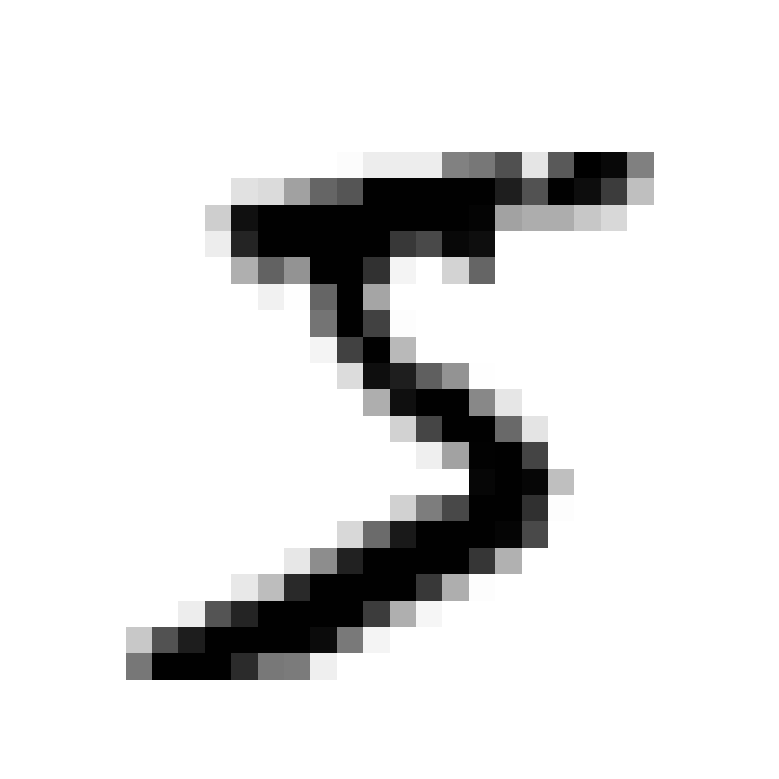

In [5]:
import matplotlib as mpl
import matplotlib.pyplot as plt

some_digit = X.iloc[0]
some_digit_image = some_digit.to_numpy().reshape(28, 28)
plt.imshow(some_digit_image, cmap="binary")
plt.axis("off")
plt.show()

In [6]:
y[0]

'5'

In [7]:
type(y[0])

str

the labels are strings, we will convert it into integer

In [8]:
import numpy as np
y = y.astype(np.uint8)

now, let's create the training and test sets

In [9]:
X_train, X_test, y_train, y_test = X[:60000].to_numpy(), X[60000:].to_numpy(), y[:60000].to_numpy(), y[60000:].to_numpy()

# Training a Binary Classifier

let's train a classifier that classifies if a digit is 5 or not

In [10]:
y_train_5 = (y_train == 5)
y_test_5 = (y_test == 5)

using *Stochastic Gradient Descent* (SGD) Classifier

In [11]:
from sklearn.linear_model import SGDClassifier

sgd_clf = SGDClassifier(random_state = 42)
sgd_clf.fit(X_train, y_train_5)

,"random_state random_state: int, RandomState instance, default=NoneUsed for shuffling the data, when ``shuffle`` is set to ``True``.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.Integer values must be in the range `[0, 2**32 - 1]`.",42
,"<a class=""param-doc-link"" style=""anchor-name: --doc-link-loss;"" rel=""noreferrer"" target=""_blank"" href=""https://scikit-learn.org/1.9/modules/generated/sklearn.linear_model.SGDClassifier.html#:~:text=loss,-%7B%27hinge%27%2C%20%27log_loss%27%2C%20%27modified_huber%27%2C%20%27squared_hinge%27%2C%20%20%20%20%20%20%20%20%27perceptron%27%2C%20%27squared_error%27%2C%20%27huber%27%2C%20%27epsilon_insensitive%27%2C%20%20%20%20%20%20%20%20%27squared_epsilon_insensitive%27%7D%2C%20default%3D%27hinge%27""> loss loss: {'hinge', 'log_loss', 'modified_huber', 'squared_hinge', 'perceptron', 'squared_error', 'huber', 'epsilon_insensitive', 'squared_epsilon_insensitive'}, default='hinge'The loss function to be used.- 'hinge' gives a linear SVM.- 'log_loss' gives logistic regression, a probabilistic classifier.- 'modified_huber' is another smooth loss that brings tolerance to outliers as well as probability estimates.- 'squared_hinge' is like hinge but is quadratically penalized.- 'perceptron' is the linear loss used by the perceptron algorithm.- The other losses, 'squared_error', 'huber', 'epsilon_insensitive' and 'squared_epsilon_insensitive' are designed for regression but can be useful in classification as well; see :class:`~sklearn.linear_model.SGDRegressor` for a description.More details about the losses formulas can be found in the :ref:`User Guide<sgd_mathematical_formulation>` and you can find a visualisation of the lossfunctions in:ref:`sphx_glr_auto_examples_linear_model_plot_sgd_loss_functions.py`.",'hinge'
,"penalty penalty: {'l2', 'l1', 'elasticnet', None}, default='l2'The penalty (aka regularization term) to be used. Defaults to 'l2'which is the standard regularizer for linear SVM models. 'l1' and'elasticnet' might bring sparsity to the model (feature selection)not achievable with 'l2'. No penalty is added when set to `None`.You can see a visualisation of the penalties in:ref:`sphx_glr_auto_examples_linear_model_plot_sgd_penalties.py`.",'l2'
,"alpha alpha: float, default=0.0001Constant that multiplies the regularization term. The higher thevalue, the stronger the regularization. Also used to compute thelearning rate when `learning_rate` is set to 'optimal'.Values must be in the range `[0.0, inf)`.",0.0001
,"l1_ratio l1_ratio: float, default=0.15The Elastic Net mixing parameter, with 0 <= l1_ratio <= 1.l1_ratio=0 corresponds to L2 penalty, l1_ratio=1 to L1.Only used if `penalty` is 'elasticnet'.Values must be in the range `[0.0, 1.0]` or can be `None` if`penalty` is not `elasticnet`... versionchanged:: 1.7 `l1_ratio` can be `None` when `penalty` is not ""elasticnet"".",0.15
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If False, thedata is assumed to be already centered.",True
,"max_iter max_iter: int, default=1000The maximum number of passes over the training data (aka epochs).It only impacts the behavior in the ``fit`` method, and not the:meth:`partial_fit` method.Values must be in the range `[1, inf)`... versionadded:: 0.19",1000
,"tol tol: float or None, default=1e-3The stopping criterion. If it is not None, training will stopwhen (loss > best_loss - tol) for ``n_iter_no_change`` consecutiveepochs.Convergence is checked against the training loss or thevalidation loss depending on the `early_stopping` parameter.Values must be in the range `[0.0, inf)`... versionadded:: 0.19",0.001
,"shuffle shuffle: bool, default=TrueWhether or not the training data should be shuffled after each epoch.",True
,"verbose verbose: int, default=0The verbosity level.Values must be in the range `[0, inf)`.",0
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-insensitive loss functions; only i

In [12]:
sgd_clf.predict([some_digit])

array([ True])

## Measuring Accuracy Using Cross-Validation

Remember that K-fold cross-validation
means splitting the training set into K folds (in this case, three), then making predictions and evaluating them on each fold using a model trained on the remaining folds

In [13]:
from sklearn.model_selection import StratifiedKFold
from sklearn.base import clone

skfolds = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

for train_index, test_index in skfolds.split(X_train, y_train_5):
    clone_clf = clone(sgd_clf)
    X_train_folds = X_train[train_index]
    y_train_folds = y_train_5[train_index]
    X_test_fold = X_train[test_index]
    y_test_fold = y_train_5[test_index]

    clone_clf.fit(X_train_folds, y_train_folds)
    y_pred = clone_clf.predict(X_test_fold)
    n_correct = sum(y_pred == y_test_fold)
    print(n_correct/len(y_pred))


0.9042
0.9477
0.96785


In [14]:
from sklearn.model_selection import cross_val_score
cross_val_score(sgd_clf, X_train, y_train_5, cv=3, scoring="accuracy")

array([0.95035, 0.96035, 0.9604 ])

the accuracy in this case is misleading, because the number of instances of our class, in this case 5 are 10%, so a model that says - "no this is not a 5" will still be right for around 90% of the time, as the following example shows.

In [15]:
from sklearn.base import BaseEstimator

class Never5Classifier(BaseEstimator):
    def fit(self, X, y=None):
        return self
    def predict(self, X):
        return np.zeros((len(X)), dtype=bool)

let's test this blind "no 5" model

In [16]:
never_5_clf = Never5Classifier()
cross_val_score(never_5_clf, X_train, y_train_5, cv=3, scoring="accuracy")

array([0.91125, 0.90855, 0.90915])

### Confusion Matrix

using cross_val_predict() method we get the predictions made by the model on the folds, made in k-fold cross validation

In [17]:
from sklearn.model_selection import cross_val_predict

y_train_pred = cross_val_predict(sgd_clf, X_train, y_train_5, cv=3)

In [18]:
from sklearn.metrics import confusion_matrix

confusion_matrix(y_train_5, y_train_pred)

array([[53892,   687],
       [ 1891,  3530]])

the *confusion_matrix* gives a sense of how much miss-classification is happening

#### Precision and Recall and F1 score

**precision** is the accuracy of positive predictions
$$
\begin{align*}
\text{precision} &= \dfrac{TP}{TP+FP}
\end{align*}
$$


**recall** or *true positive rate* or *sensitivity* is the ratio of positive instances that are correctly detected by classifier

$$
\begin{align*}
\text{recall} &= \dfrac{TP}{TP+FN}
\end{align*}
$$

In [19]:
from sklearn.metrics import precision_score, recall_score

print(f"precision score = {precision_score(y_train_5, y_train_pred)}")
print(f"recall score    = {recall_score(y_train_5, y_train_pred)}")

precision score = 0.8370879772350012
recall score    = 0.6511713705958311


$F_1$ score is the harmonic mean of precision and recall

$$
\begin{align*}
F_1\text{ score} &= \dfrac{2}{\dfrac{1}{precision}+\dfrac{1}{recall}} \\[6pt]
&= \dfrac{TP}{TP+\dfrac{FN+FP}{2}}
\end{align*}
$$

In [20]:
from sklearn.metrics import f1_score

f1_score(y_train_5, y_train_pred)

0.7325171197343847

#### Precision/Recall Trade-off

The `SGDClassifier` uses a threshold of 0, we can access the decision_function of a classifier which gives us the before threshold value of model's prediction. But how do we know, which threshold to use? By trying different thresholds, we can get an idea of what threshold we should use

In [21]:
y_scores = cross_val_predict(sgd_clf, X_train, y_train_5, cv=3, method="decision_function")

In [22]:
from sklearn.metrics import precision_recall_curve

precisions, recalls, thresholds = precision_recall_curve(y_train_5, y_scores) 

In [23]:
def plot_precision_recall_vs_threshold(precisions, recalls, thresholds):
    plt.plot(thresholds, precisions[:-1], "b--", label="Precision")
    plt.plot(thresholds, recalls[:-1], "g-", label="Recall")
    plt.grid()

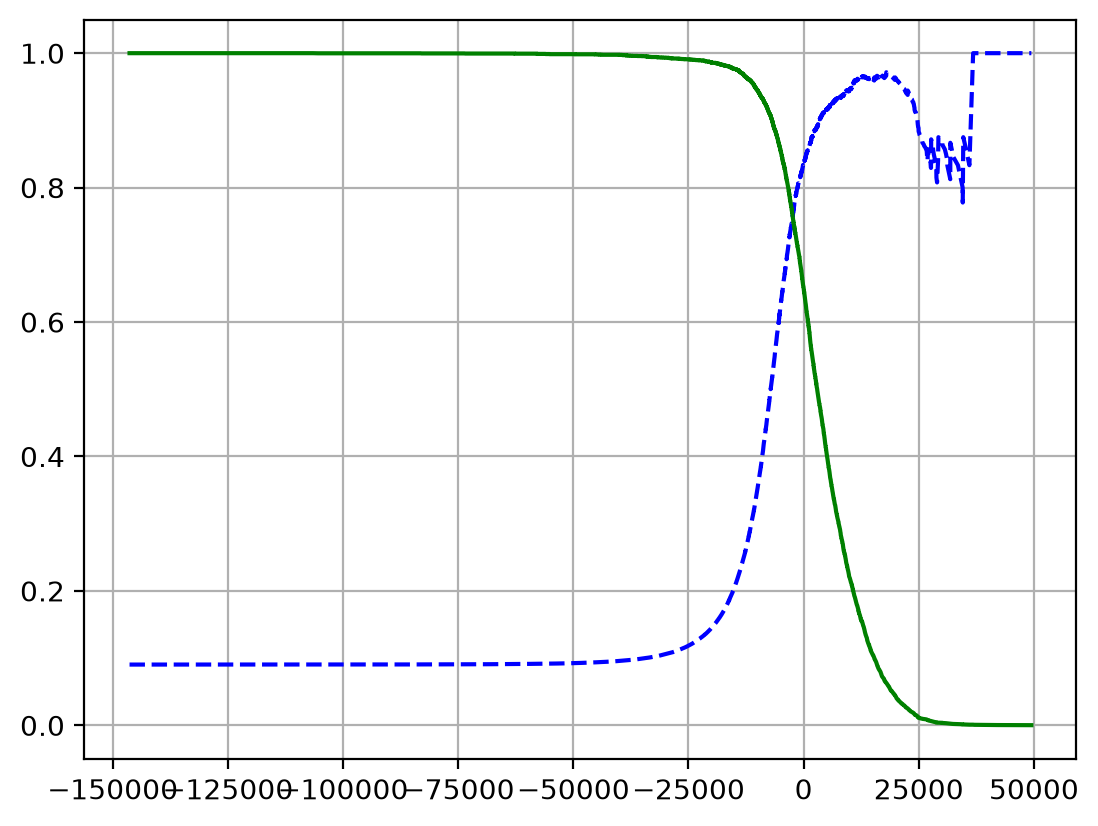

In [24]:
plot_precision_recall_vs_threshold(precisions, recalls, thresholds)

observer that the precision curve is bumpier than that of the recall curve, why? -- *page 95*

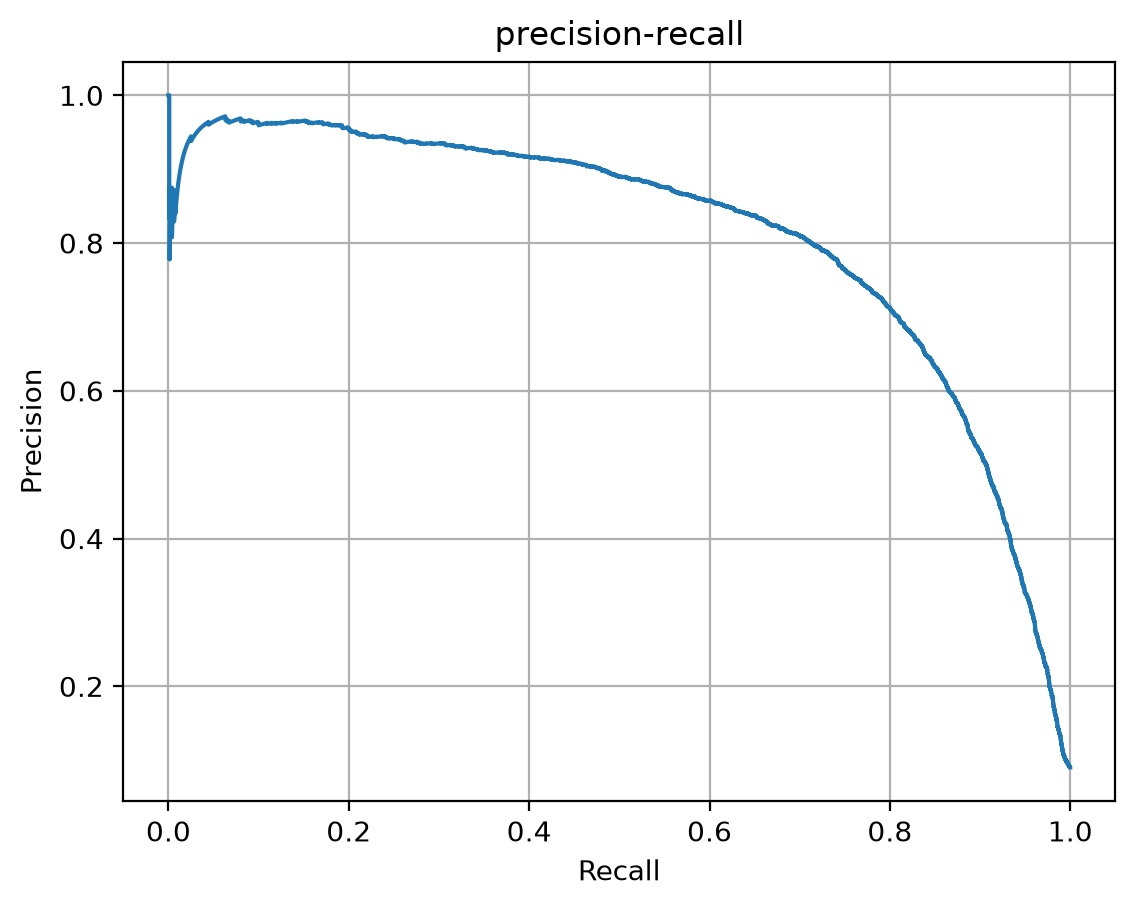

In [25]:
plt.plot(recalls, precisions)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("precision-recall")
plt.grid()

find a threshold that can give 90% precision

In [26]:
threshold_90_precision = thresholds[np.argmax(precisions>0.90)]
print(f"the threshold for 90% accuracy = {threshold_90_precision}")

y_train_pred_90 = (y_scores >= threshold_90_precision)
print(f"precision score with this threshold = {precision_score(y_train_5, y_train_pred_90)}")
print(f"recall score with this threshold    = {recall_score(y_train_5, y_train_pred_90)}")

the threshold for 90% accuracy = 3370.0194991439557
precision score with this threshold = 0.9000345901072293
recall score with this threshold    = 0.4799852425751706


so that means we can develop a classifier with arbitrary precision or arbitrary recall, as we know precision and recall are not that great of measures

### The ROC Curve

*receiver oprating charactersistic* (ROC) curve - plots *true positive rate* vs *false positive rate* - *TPR/FPR* - TPR $\equiv$ recall  
*FPR* is the ratio of negative instances that are incorrectly classified as positive  
*TNR* is the ratio of negative instances that are correctly classified as negative  
*TNR* is also called as *specificity*  
hence the *ROC* curve plots **sensitivity vs 1-specificity**, it is used with binary classifiers.

$$
\begin{align*}
FPR&=1-TNR
\end{align*}
$$

In [27]:
def plot_roc_curve(fpr, tpr, label=None):
    plt.plot([0,1],[0,1],'k--')
    plt.xlabel("FPR")
    plt.ylabel("TPR (recall)")
    plt.grid()
    plt.plot(fpr,tpr,linewidth=2,label=label)

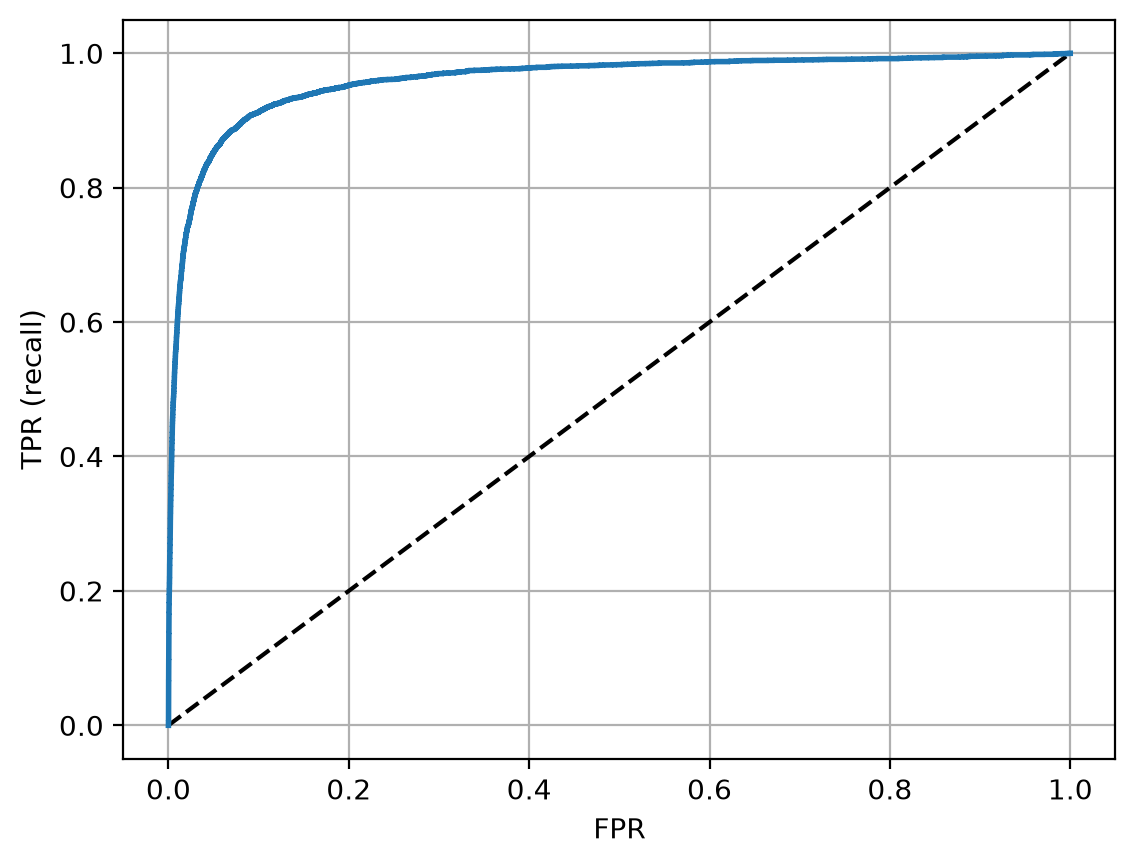

In [28]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_train_5, y_scores)
plot_roc_curve(fpr,tpr)
plt.show()

a perfect classifier has ROC AUC *(area under curve)* = 1  
because it will have 100% recall  
let's calculate the auc for our `sgd_clf`

In [29]:
from sklearn.metrics import roc_auc_score

print(f"ROC AUC = {roc_auc_score(y_train_5, y_scores)}")

ROC AUC = 0.9604938554008616


#### NOTE

use PR curve whenever the positive class is rare or when you care about more false positives than false negatives, otherwise use ROC

### using random forest classifier

In [30]:
from sklearn.ensemble import RandomForestClassifier

forest_clf = RandomForestClassifier(random_state=42)
y_probas_forest = cross_val_predict(forest_clf, X_train, y_train_5, cv=3, method="predict_proba")

In [31]:
y_scores_forest = y_probas_forest[:,1]
fpr_forest, tpr_forest, thresholds_forest = roc_curve(y_train_5, y_scores_forest)

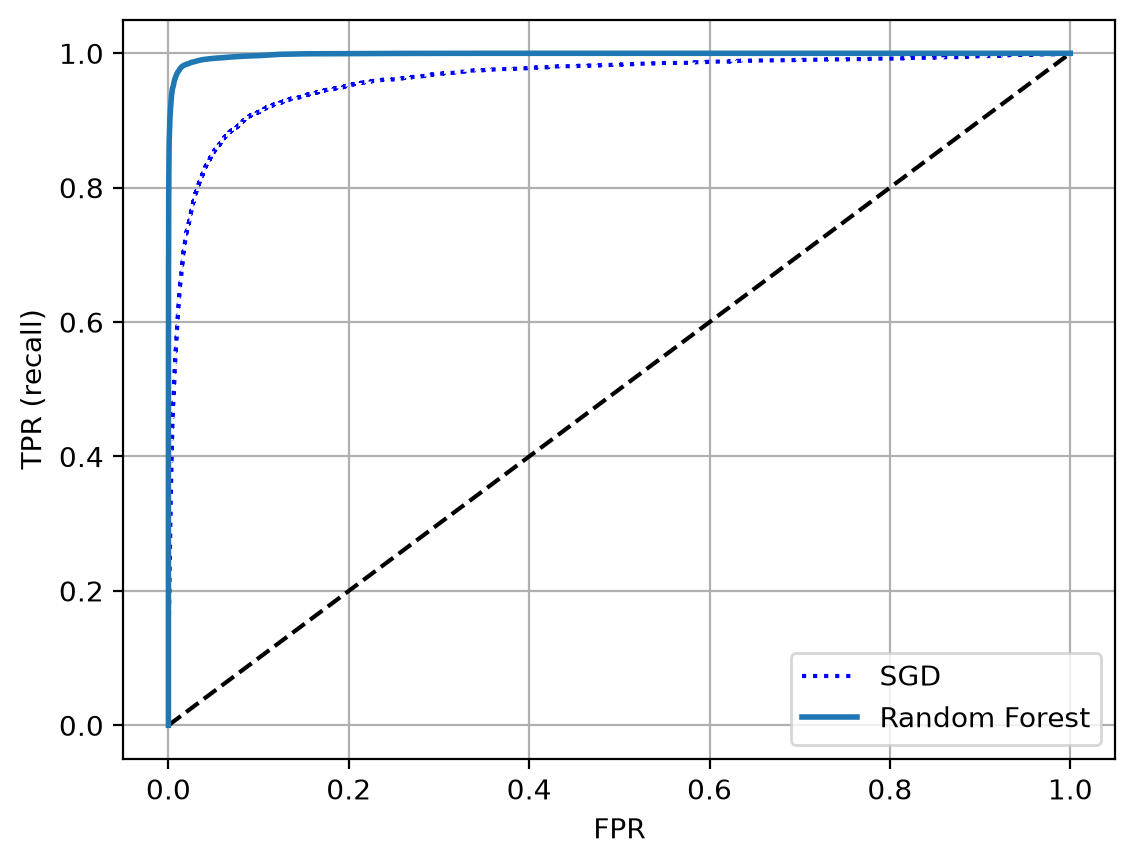

In [32]:
plt.plot(fpr, tpr, "b:", label="SGD")
plot_roc_curve(fpr_forest, tpr_forest, label="Random Forest")
plt.legend(loc="lower right")
plt.show()

the random forest classifier's roc curve looks far better than the SGD one, and hence the roc auc is also much better

In [33]:
print(f"the ROC-AUC for random forest classifier is {roc_auc_score(y_train_5, y_scores_forest)}")

the ROC-AUC for random forest classifier is 0.9983436731328145


### Workflow for setting up binary classifier

* choose a binary classifier model
* choose an appropriate metric for task
* evaluate the classifier using cross-vallidation
* select precision/recall trade-off that fits your needs
* user ROC, ROC-AUC score for comparing various models

# Multiclass Classification

called as multiclass or multinomial classifiers, they can distinguish between more than two calsses.  
ways to create multiclass classifier from multiple binary classifiers

* OvR - *one-versus-the-rest* or *one-versus-all* strategy : train a binary classifier for each of the class, and at prediction give classify the instance accorcding to the most confident classifier
* OvO - *one-versus-one* strategy : train $\binom{n}{2}$ classifiers on pairs of classes

The main advantage of OvO is that a classifier in it only needs to be trained on a part of the training data so training a single classifier is faster and multiple classifiers can be trained in parallel  
Some algorithms such as SVM scale poorly with training data set size. For these algorithms OvO is perferred because it is faster to train many classifiers on small data than to train few calssifiers on large data.  
For most binary classification algorithms, OvR is preferred

In [34]:
from sklearn.svm import SVC

svm_clf = SVC()
svm_clf.fit(X_train, y_train)
svm_clf.predict([some_digit])

array([5], dtype=uint8)

In [35]:
some_digit_scores = svm_clf.decision_function([some_digit])

np.argmax(some_digit_scores)

np.int64(5)

In [36]:
svm_clf.classes_

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=uint8)

In [37]:
svm_clf.classes_[5]

np.uint8(5)

to force OvO or OvR we can use the following classes in scikit learn:
* `OneVsOneClassifier`
* `OneVsRestClassifier`

as shown in the following code

In [ ]:
from sklearn.multiclass import OneVsRestClassifier

ovr_clf = OneVsRestClassifier(SVC())
ovr_clf.fit(X_train, y_train)

In [ ]:
ovr_clf.predict([some_digit])

In [ ]:
len(ovr_clf.estimators_)

the SGDClassifier takes less time than above strategies as this one trains a single model, and above OvR and OvO train multiple classifiers. SGDClassifier is a multiclass classifier by default

In [ ]:
sgd_clf.fit(X_train, y_train)

In [ ]:
sgd_clf.predict([some_digit])

In [ ]:
sgd_clf.decision_function([some_digit])

evaluating using `cross_val_score` function

In [ ]:
cross_val_score(sgd_clf, X_train, y_train, cv=3, scoring="accuracy")

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train.astype(np.float64))
cross_val_score(sgd_clf, X_train_scaled, y_train, cv=3, scoring="accuracy")

## Error Analysis

look at the confusion matrix.

In [ ]:
y_train_pred = cross_val_predict(sgd_clf, X_train_scaled, y_train, cv=3)
conf_mx = confusion_matrix(y_train, y_train_pred)
conf_mx

In [ ]:
plt.matshow(conf_mx, cmap=plt.cmap.gray)
plt.show()

need to divide each value in the confusion
matrix by the number of images in the corresponding class so that you can compare
error rates instead of absolute numbers of errors (which would make abundant
classes look unfairly bad)

In [ ]:
row_sums = conf_mx.sum(axis=1, keepdims=True)
norm_conf_mx = conf_mx / row_sums

fill the diagonal with zeros, keep only the errors and plot the result

In [ ]:
np.fill_diagonal(norm_conf_mx, 0)
plt.matshow(norm_conf_mx, cmap=plt.cmap.gray)
plt.show()

# Multilabel Classification

A classifier that can associate more than one class to an instance, eg., detecting several object in a figure.

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

y_train_large = (y_train >= 7)
y_train_odd = (y_train % 2 == 1)
y_multilabel = np.c_[y_train_large, y_train_odd]

knn_clf = KNeighborsClassifier()
knn_clf.fit(X_train, y_multilabel)

In [ ]:
knn_clf.predict([some_digit])

In [ ]:
y_train_knn_pred = cross_val_predict(knn_clf, X_train, y_multilabel, cv=3)
f1_score(y_multilabel, y_train_knn_pred, average="macro")

# Multioutput Classification

*multioutput-multiclass classification*: here each label can be multiclass (it can have more than two possible values)

In [ ]:
noise = np.random.randint(0, 100, (len(X_train), 784))
X_train_mod = X_train + noise
noise = np.random.randint(0, 100, (len(X_test), 784))
X_test_mod = X_test + noise
y_train_mod = X_train
y_test_mod = X_test

In [ ]:
knn_clf.fit(X_train_mod, y_train_mod)
clean_digit = knn_clf.predict([X_test_mod[some_index]])
plot_digit(clean_digit)